---
title: "Duncan–Toor ternary gas diffusion"
description: "The two-bulb experiment where Fick's law provably fails: nitrogen diffuses uphill, stops against its own gradient, then reverses."
categories: [sec:A, struct:S3, struct:S9, tier:T0, data:tier4, phase:gas]
date: 2026-07-25
---

# Duncan–Toor ternary gas diffusion

**Catalog ID:** `A4.9` · **Structures:** `S3` (1D steady BVP), `S9` (implicit
multicomponent flux) · **Tier:** T0

In a ternary mixture, a species can diffuse *up* its own concentration gradient,
stop dead while a gradient persists, and then reverse direction. Fick's law
cannot produce any of these. This page reproduces the experiment that made that
concrete, and shows the Maxwell–Stefan solve that explains it.

## Background

Fick's law says a species moves down its own concentration gradient. For binary
mixtures that is essentially always true. For three or more species it is not,
because each species is dragged by every other one.

Duncan and Toor (1962) built the cleanest possible demonstration: two bulbs of
gas joined by a thin capillary. Bulb 1 holds nitrogen and carbon dioxide; bulb 2
holds hydrogen and nitrogen. The nitrogen mole fraction is *almost identical in
both bulbs* — it has essentially no gradient to drive it. Fick's law therefore
predicts that nitrogen simply sits there while H₂ and CO₂ exchange.

It does not. Nitrogen shows, in sequence:

1. **osmotic diffusion** — a nonzero flux at zero gradient (t = 0),
2. **uphill (reverse) diffusion** — flux *up* its own gradient, so a gradient
   builds where there was none,
3. **a diffusion barrier** — zero flux while a large gradient exists (at the
   turning point),
4. and only then ordinary downhill diffusion.

The experiment is small, the geometry is simple, and the failure of Fick's law
is unambiguous. That makes it the best possible opening demonstration of why a
multicomponent transport library is worth having.

## The published model

**Maxwell–Stefan.** For an ideal gas mixture of $n$ species at uniform
temperature and pressure, the driving force on species $i$ is balanced by
friction with every other species:

$$
\nabla x_i \;=\; \sum_{j \neq i} \frac{x_i N_j - x_j N_i}{c_t\,\mathrm{D}_{ij}}
$$

with $x_i$ the mole fraction, $N_i$ the molar flux, $c_t$ the total molar
concentration, and $\mathrm{D}_{ij}$ the Maxwell–Stefan diffusivity of the
$i\!-\!j$ pair. The capillary is closed and isobaric, so

$$
\sum_{i=1}^{n} N_i = 0 .
$$

**Matrix form.** Eliminating species $n$ gives $n-1$ independent equations that
can be inverted for the fluxes,

$$
(N) = -\,c_t\,[B]^{-1}\,(\nabla x), \qquad
B_{ii} = \frac{x_i}{\mathrm{D}_{in}} + \sum_{k \neq i}\frac{x_k}{\mathrm{D}_{ik}},
\qquad
B_{ij} = -x_i\!\left(\frac{1}{\mathrm{D}_{ij}} - \frac{1}{\mathrm{D}_{in}}\right).
$$

$[B]$ depends on composition, so the flux of each species depends on the
gradients of *all* of them. That coupling is the entire phenomenon: the
off-diagonal terms let $N_i$ be nonzero when $\nabla x_i = 0$.

**Capillary and bulbs.** The capillary volume is ~0.3% of a bulb volume, so it is
quasi-steady: at each instant $\nabla\!\cdot\!N_i = 0$, and $N_i$ is uniform
along the capillary. The bulbs are well mixed:

$$
V_1 c_t \frac{\mathrm{d}x_{i,1}}{\mathrm{d}t} = -A\,N_i , \qquad
V_2 c_t \frac{\mathrm{d}x_{i,2}}{\mathrm{d}t} = +A\,N_i .
$$

| Symbol | Code | Meaning |
|---|---|---|
| $x_i$ | `x[:, i]` | mole fraction in the capillary, cell-centred |
| $x_{i,1}, x_{i,2}$ | `xb1`, `xb2` | bulb compositions (the boundary values) |
| $N_i$ | `flux(...)` | molar flux at capillary faces |
| $[B]$ | `build_b(...)` | Maxwell–Stefan resistance matrix |
| $\mathrm{D}_{ij}$ | `d_ms` | MS pair diffusivities |
| $c_t$ | `c_t` | total molar concentration |

## Parameters and assumptions

**Assumptions:** ideal gas; isothermal and isobaric; capillary quasi-steady
(justified below); bulbs perfectly mixed; no viscous or thermal diffusion.

> **Provenance warning.** The geometry, initial compositions, and MS
> diffusivities below are the values commonly tabulated for this experiment.
> They have **not** been checked against the original article for this page.
> Verify them against Duncan & Toor (1962) before citing any number from here.
> The qualitative sequence (osmotic → uphill → barrier → downhill) is robust to
> modest changes in these values; the quantitative timing is not.

In [1]:
# Colab environment cell — no-op if pymrm is already installed
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

# Make shared/gallery_utils.py importable locally and on Colab
if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/pymrm/pymrm-gallery/"
               "main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from pymrm import construct_grad, construct_div, NumJac, newton
from gallery_utils import load_data, load_meta, cite_data, report_agreement, nrmse

PAGE = "A4.9-duncan-toor"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [3]:
# --- Physical constants and cell geometry -----------------------------------
T      = 308.35        # K       temperature
p      = 101.325e3     # Pa      pressure
R_GAS  = 8.314462      # J/(mol K)
c_t    = p / (R_GAS * T)          # mol/m3   total molar concentration

length = 85.9e-3       # m       capillary length
d_cap  = 2.08e-3       # m       capillary diameter
area   = 0.25 * np.pi * d_cap**2  # m2
vol_1  = 77.99e-6      # m3      bulb 1
vol_2  = 78.63e-6      # m3      bulb 2

# --- Species: 0 = H2, 1 = N2, 2 = CO2 ---------------------------------------
SPECIES = ["H$_2$", "N$_2$", "CO$_2$"]

d_ms = np.zeros((3, 3))                       # Maxwell-Stefan diffusivities, m2/s
d_ms[0, 1] = d_ms[1, 0] = 83.3e-6             # H2  - N2
d_ms[0, 2] = d_ms[2, 0] = 68.0e-6             # H2  - CO2
d_ms[1, 2] = d_ms[2, 1] = 16.8e-6             # N2  - CO2

x1_0 = np.array([0.00000, 0.50086, 0.49914])  # bulb 1 initial composition
x2_0 = np.array([0.50121, 0.49879, 0.00000])  # bulb 2 initial composition

t_end = 20 * 3600.0    # s
n_z   = 40             # capillary cells
n_i   = 2              # independent mole fractions (n_c - 1)

print(f"c_t = {c_t:.2f} mol/m3")
print(f"capillary volume / bulb volume = {area*length/vol_1:.4%}  -> quasi-steady")
print(f"initial N2 difference between bulbs = {x1_0[1]-x2_0[1]:+.5f}  (essentially zero)")

c_t = 39.52 mol/m3
capillary volume / bulb volume = 0.3743%  -> quasi-steady
initial N2 difference between bulbs = +0.00207  (essentially zero)


## The data

Experimental bulb compositions versus time, digitised from the original article.

In [4]:
data = load_data("duncan-toor-1962-run1.csv", page=PAGE)
meta = load_meta("duncan-toor-1962-run1.csv", page=PAGE)

HAS_DATA = len(data) > 0
print(cite_data(meta))
if HAS_DATA:
    display(data.head())
else:
    print("\n" + "=" * 72)
    print("NO EXPERIMENTAL POINTS YET — this page currently shows simulation only.")
    print("The CSV is a schema placeholder. To complete the page, digitise the")
    print("bulb-composition-vs-time figure of Duncan & Toor (1962) into")
    print(f"  pages/{PAGE}/data/duncan-toor-1962-run1.csv")
    print("and fill in the acquisition block of the .meta.yaml sidecar.")
    print("See docs/data-strategy.md for the extraction and provenance rules.")
    print("=" * 72)

Duncan, J. B.; Toor, H. L. (1962) — AIChE Journal 8(1) 38-41 — doi:10.1002/aic.690080112 — digitised from TODO

NO EXPERIMENTAL POINTS YET — this page currently shows simulation only.
The CSV is a schema placeholder. To complete the page, digitise the
bulb-composition-vs-time figure of Duncan & Toor (1962) into
  pages/A4.9-duncan-toor/data/duncan-toor-1962-run1.csv
and fill in the acquisition block of the .meta.yaml sidecar.
See docs/data-strategy.md for the extraction and provenance rules.


## PyMRM implementation

The capillary is discretised with `construct_grad` and `construct_div`. Three
points worth noting, because they are the reusable part:

- **The bulb compositions are external unknowns, not fixed boundary data.** The
  `shapes_d` argument of `construct_grad` returns *separate constant matrices*
  that multiply the boundary values. All operators are therefore assembled once,
  even though the boundary conditions change at every time step.
- **The flux is implicit** (structure `S9`): at every face we build $[B]$ from
  the local composition and solve a small linear system. `np.linalg.solve`
  broadcasts over all faces at once.
- **`NumJac` needs a neighbour stencil.** The residual in a cell depends on its
  neighbours through the fluxes, so `axes_diagonals=[0]`; and all species couple
  at a point, so `axes_blocks=[-1]`.

In [5]:
shape = (n_z, n_i)
z_f = np.linspace(0.0, length, n_z + 1)          # face coordinates
z_c = 0.5 * (z_f[:-1] + z_f[1:])                 # cell centres

# Dirichlet at both ends: a*dx/dn + b*x = d with d = 1 so that the boundary
# value enters through the shapes_d matrices instead of a constant vector.
bc = ({"a": 0.0, "b": 1.0, "d": 1.0},            # z = 0   -> bulb 1 composition
      {"a": 0.0, "b": 1.0, "d": 1.0})            # z = L   -> bulb 2 composition

grad_mat, grad_bc_1, grad_bc_2 = construct_grad(
    shape, z_f, z_c, bc, axis=0, shapes_d=((1, n_i), (1, n_i)))
div_mat = construct_div(shape, z_f, nu=0, axis=0)          # nu=0: Cartesian
numjac = NumJac(shape, axes_diagonals=[0], axes_blocks=[-1])

In [6]:
def build_b(x_ind):
    """Maxwell-Stefan matrix [B], shape (..., 2, 2), from independent fractions."""
    x = np.concatenate([x_ind, 1.0 - x_ind.sum(axis=-1, keepdims=True)], axis=-1)
    b = np.zeros(x_ind.shape[:-1] + (2, 2))
    for i in range(n_i):
        acc = x[..., i] / d_ms[i, 2]
        for k in range(3):
            if k != i:
                acc = acc + x[..., k] / d_ms[i, k]
        b[..., i, i] = acc
        for j in range(n_i):
            if j != i:
                b[..., i, j] = -x[..., i] * (1.0 / d_ms[i, j] - 1.0 / d_ms[i, 2])
    return b


def flux(x, xb1, xb2):
    """Molar fluxes at all capillary faces, shape (n_z+1, 2)."""
    grad_x = (grad_mat @ x.reshape((-1, 1))
              + grad_bc_1 @ xb1[:n_i].reshape((-1, 1))
              + grad_bc_2 @ xb2[:n_i].reshape((-1, 1))).reshape(n_z + 1, n_i)
    x_face = np.empty((n_z + 1, n_i))
    x_face[1:-1] = 0.5 * (x[:-1] + x[1:])
    x_face[0], x_face[-1] = xb1[:n_i], xb2[:n_i]
    return -c_t * np.linalg.solve(build_b(x_face), grad_x[..., None])[..., 0]


def solve_capillary(x_init, xb1, xb2):
    """Steady Maxwell-Stefan profile in the capillary for given bulb compositions."""
    def residual(x):
        g, jac = numjac(
            lambda xx: (div_mat @ flux(xx, xb1, xb2).reshape((-1, 1))).reshape(shape), x)
        return g.reshape((-1, 1)), jac
    result = newton(residual, x_init, maxfev=30, tol=1e-12)
    return result.x.reshape(shape), result.success

In [7]:
def simulate(n_steps=400, t_end=t_end):
    """Backward-Euler march of the bulb compositions, capillary quasi-steady."""
    dt = t_end / n_steps
    xb1, xb2 = x1_0.copy(), x2_0.copy()
    x = np.linspace(0, 1, n_z)[:, None] * (xb2[:n_i] - xb1[:n_i]) + xb1[:n_i]
    t_hist, x1_hist, x2_hist = [0.0], [xb1.copy()], [xb2.copy()]
    converged = True

    for _ in range(n_steps):
        xb1_new, xb2_new = xb1.copy(), xb2.copy()
        for _ in range(3):                      # inner iterations on the coupling
            x, ok = solve_capillary(x, xb1_new, xb2_new)
            converged &= ok
            n_face = flux(x, xb1_new, xb2_new)
            xb1_new[:n_i] = xb1[:n_i] - area * n_face[0] / (vol_1 * c_t) * dt
            xb2_new[:n_i] = xb2[:n_i] + area * n_face[-1] / (vol_2 * c_t) * dt
            xb1_new[2] = 1.0 - xb1_new[:n_i].sum()
            xb2_new[2] = 1.0 - xb2_new[:n_i].sum()
        xb1, xb2 = xb1_new, xb2_new
        t_hist.append(t_hist[-1] + dt)
        x1_hist.append(xb1.copy())
        x2_hist.append(xb2.copy())

    return (np.asarray(t_hist) / 3600.0, np.asarray(x1_hist),
            np.asarray(x2_hist), converged)


t_h, x_bulb1, x_bulb2, ok = simulate()
print("all Newton solves converged:", ok)

all Newton solves converged: True


## Results

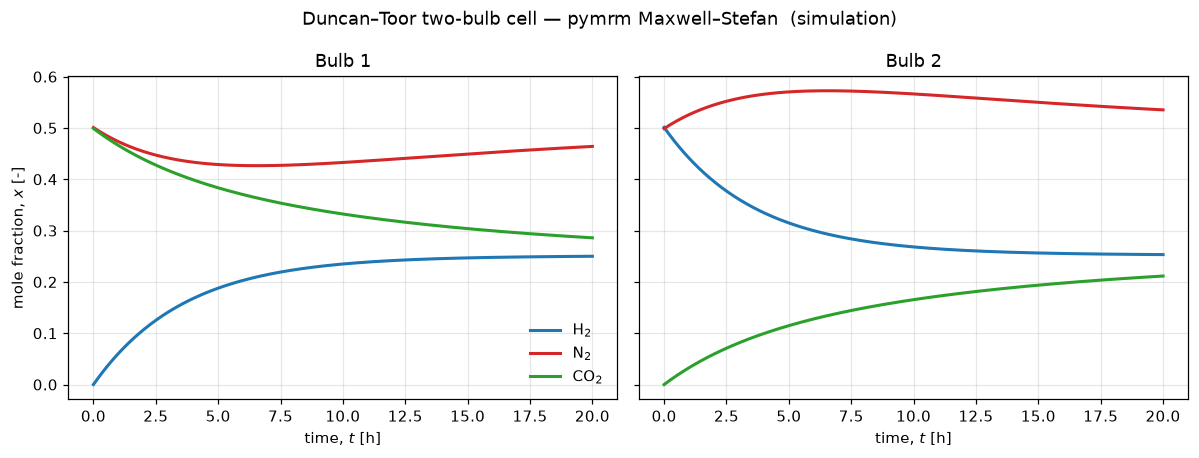

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
colours = ["tab:blue", "tab:red", "tab:green"]

for ax, xb, name in zip(axes, (x_bulb1, x_bulb2), ("Bulb 1", "Bulb 2")):
    for i, (sp, col) in enumerate(zip(SPECIES, colours)):
        ax.plot(t_h, xb[:, i], color=col, lw=2, label=sp)
    ax.set_xlabel("time, $t$ [h]")
    ax.set_title(name)
axes[0].set_ylabel("mole fraction, $x$ [-]")
axes[0].legend(frameon=False)

if HAS_DATA:
    for ax, side in zip(axes, (1, 2)):
        sub = data[data["bulb"] == side]
        for i, col in enumerate(colours):
            m = sub[sub["species"] == ["H2", "N2", "CO2"][i]]
            ax.plot(m["time_h"], m["x"], "o", color=col, ms=5,
                    mfc="none", label="_nolegend_")

fig.suptitle("Duncan–Toor two-bulb cell — pymrm Maxwell–Stefan"
             + ("  (lines) vs experiment (points)" if HAS_DATA else "  (simulation)"))
fig.tight_layout()
plt.show()

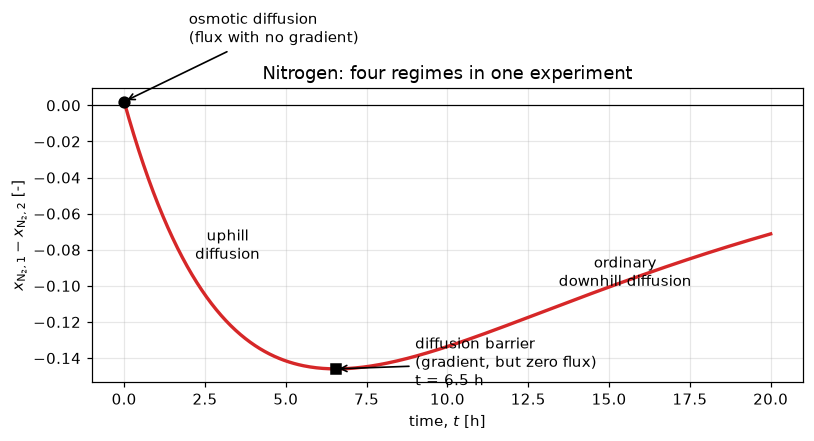

N2 difference at t=0      : +0.00207   (essentially zero)
N2 difference at the peak : -0.14599   at t = 6.55 h
N2 difference at t=20 h    : -0.07121


In [9]:
# The nitrogen signal is the whole point: plot its difference between bulbs.
dx_n2 = x_bulb1[:, 1] - x_bulb2[:, 1]
i_peak = int(np.argmax(np.abs(dx_n2)))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(t_h, dx_n2, color="tab:red", lw=2.2)
ax.axhline(0.0, color="k", lw=0.8)
ax.plot(0, dx_n2[0], "o", color="k", ms=7, zorder=5)
ax.plot(t_h[i_peak], dx_n2[i_peak], "s", color="k", ms=7, zorder=5)

ax.annotate("osmotic diffusion\n(flux with no gradient)", xy=(0, dx_n2[0]),
            xytext=(2.0, 0.035), arrowprops=dict(arrowstyle="->", lw=1.1))
ax.annotate(f"diffusion barrier\n(gradient, but zero flux)\nt = {t_h[i_peak]:.1f} h",
            xy=(t_h[i_peak], dx_n2[i_peak]), xytext=(9.0, -0.155),
            arrowprops=dict(arrowstyle="->", lw=1.1))
ax.annotate("uphill\ndiffusion", xy=(3.2, -0.085), xytext=(3.2, -0.085), ha="center")
ax.annotate("ordinary\ndownhill diffusion", xy=(15.5, -0.10), ha="center")

ax.set_xlabel("time, $t$ [h]")
ax.set_ylabel(r"$x_{\mathrm{N_2},1} - x_{\mathrm{N_2},2}$ [-]")
ax.set_title("Nitrogen: four regimes in one experiment")
fig.tight_layout()
plt.show()

print(f"N2 difference at t=0      : {dx_n2[0]:+.5f}   (essentially zero)")
print(f"N2 difference at the peak : {dx_n2[i_peak]:+.5f}   at t = {t_h[i_peak]:.2f} h")
print(f"N2 difference at t={t_h[-1]:.0f} h    : {dx_n2[-1]:+.5f}")

Nitrogen starts with a difference of about 0.002 between the bulbs — nothing —
and yet within a few hours it has separated to a difference of about 0.15. It
moved *away* from uniformity, driven entirely by friction with the hydrogen and
carbon dioxide streaming past it in opposite directions. At the marked turning
point its flux is zero while the gradient is at its largest. Only after that
does it behave the way Fick's law says it always should.

## Validation

Three independent checks, none of which uses the experimental data.

In [10]:
# 1. Quasi-steady capillary: the flux must be uniform along it.
x_ss, _ = solve_capillary(np.linspace(0, 1, n_z)[:, None]
                          * (x2_0[:n_i] - x1_0[:n_i]) + x1_0[:n_i], x1_0, x2_0)
n_face = flux(x_ss, x1_0, x2_0)
flux_spread = np.max(np.abs(n_face - n_face.mean(axis=0))) / np.max(np.abs(n_face))
print(f"1. flux non-uniformity along capillary : {flux_spread:.3e}   (steady state)")

# 2. Species conservation: total moles of each species are fixed.
total_0 = vol_1 * x1_0 + vol_2 * x2_0
total_1 = vol_1 * x_bulb1[-1] + vol_2 * x_bulb2[-1]
mole_error = np.max(np.abs(total_1 - total_0)) / total_0.sum()
print(f"2. species mole-balance error          : {mole_error:.3e}")

# 3. Time-step independence: halve dt and compare.
t_fine, x1_fine, _, _ = simulate(n_steps=800)
dt_error = np.max(np.abs(np.interp(t_h, t_fine, x1_fine[:, 1]) - x_bulb1[:, 1]))
print(f"3. max N2 change on halving dt         : {dt_error:.3e}")

metrics = {"flux_nonuniformity": flux_spread,
           "mole_balance_error": mole_error,
           "timestep_sensitivity": dt_error}
if HAS_DATA:
    pass  # add nrmse(model, experiment) here once the CSV is filled in
report_agreement("A4.9", metrics)

1. flux non-uniformity along capillary : 1.935e-14   (steady state)
2. species mole-balance error          : 4.327e-16


3. max N2 change on halving dt         : 1.692e-04
Agreement metrics for A4.9:
  flux_nonuniformity   = 1.9355e-14
  mole_balance_error   = 4.3266e-16
  timestep_sensitivity = 0.00016919


{'page': 'A4.9',
 'metrics': {'flux_nonuniformity': 1.9354963477142276e-14,
  'mole_balance_error': 4.3265633878396133e-16,
  'timestep_sensitivity': 0.0001691880535750201}}

## What pymrm adds

The original analysis used Toor's **linearised** theory: freeze $[B]$ at the
average composition, which turns the problem into a matrix exponential. That is
what made the phenomenon explicable in 1962, and it captures all four regimes.

What it cannot do is let $[B]$ vary along the capillary. Here the composition
swings from $(0,\,0.50,\,0.50)$ to $(0.50,\,0.50,\,0)$ across 86 mm, and the
H₂–CO₂ and N₂–CO₂ diffusivities differ by a factor of four, so $[B]$ is far from
constant. The cell below quantifies the difference the linearisation makes.

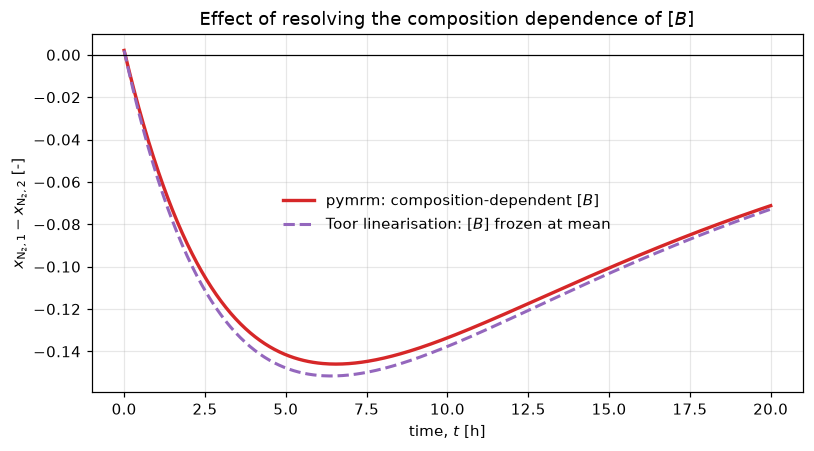

max deviation of the linearised solution in the N2 signal: 0.0066
as a fraction of the peak N2 separation                  : 4.5%


In [11]:
from scipy.linalg import expm

# Toor's linearised solution: [B] frozen at the arithmetic mean composition.
x_avg = 0.5 * (x1_0 + x2_0)
b_avg = build_b(x_avg[None, :n_i])[0]
beta = (c_t * area / length) * (1.0 / (vol_1 * c_t) + 1.0 / (vol_2 * c_t)) \
       * np.linalg.inv(b_avg)

dx0 = (x1_0 - x2_0)[:n_i]
dx_lin = np.array([expm(-beta * (tt * 3600.0)) @ dx0 for tt in t_h])

dx_full = x_bulb1[:, :n_i] - x_bulb2[:, :n_i]
lin_dev = np.max(np.abs(dx_lin[:, 1] - dx_full[:, 1]))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(t_h, dx_full[:, 1], color="tab:red", lw=2.2,
        label="pymrm: composition-dependent $[B]$")
ax.plot(t_h, dx_lin[:, 1], "--", color="tab:purple", lw=2,
        label="Toor linearisation: $[B]$ frozen at mean")
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xlabel("time, $t$ [h]")
ax.set_ylabel(r"$x_{\mathrm{N_2},1} - x_{\mathrm{N_2},2}$ [-]")
ax.set_title("Effect of resolving the composition dependence of $[B]$")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"max deviation of the linearised solution in the N2 signal: {lin_dev:.4f}")
print(f"as a fraction of the peak N2 separation                  : "
      f"{lin_dev/np.max(np.abs(dx_full[:,1])):.1%}")

In [12]:
# Fick's law with Wilke effective diffusivities, for contrast.
def wilke_deff(x, i):
    return (1.0 - x[i]) / sum(x[j] / d_ms[i, j] for j in range(3) if j != i)

print("Wilke effective diffusivities at the mean composition [1e-6 m2/s]:")
for i, sp in enumerate(["H2", "N2", "CO2"]):
    print(f"  {sp:<4}: {wilke_deff(x_avg, i)*1e6:6.2f}")
print()
print(f"Initial N2 gradient across the capillary: {(x1_0[1]-x2_0[1])/length:+.4f} 1/m")
print("Fick + Wilke therefore gives N2 an essentially zero flux at t = 0,")
print("and by symmetry it never develops one: N2 stays flat for all time.")
print(f"The Maxwell-Stefan solution separates N2 by "
      f"{abs(dx_full[:,1]).max():.3f} mole fraction. Fick predicts ~0.")

Wilke effective diffusivities at the mean composition [1e-6 m2/s]:
  H2  :  77.49
  N2  :  28.00
  CO2 :  22.44

Initial N2 gradient across the capillary: +0.0241 1/m
Fick + Wilke therefore gives N2 an essentially zero flux at t = 0,
and by symmetry it never develops one: N2 stays flat for all time.
The Maxwell-Stefan solution separates N2 by 0.146 mole fraction. Fick predicts ~0.


So there are two distinct improvements over the published treatment:

1. **Against Fick's law** — not a refinement but a qualitative correction. Fick
   predicts nitrogen never moves; it moves a lot.
2. **Against Toor's linearisation** — a quantitative correction of a few percent
   of the peak separation, obtained by resolving $[B]$ along the capillary
   instead of freezing it. Small here, but it grows with the spread in the pair
   diffusivities, and there is no extra cost: it is the same solve.

## Reuse

**To adapt this page to your system**, change in order:

| Change | Where |
|---|---|
| Different species or more of them | `SPECIES`, `d_ms`, `x1_0`, `x2_0`, and `n_i = n_c - 1` |
| Different cell geometry | `length`, `d_cap`, `vol_1`, `vol_2` |
| Non-ideal mixture | multiply $[B]^{-1}$ by the thermodynamic factor $[\Gamma]$ in `flux` |
| Porous medium instead of an open capillary | add Knudsen terms to $[B]$ — this becomes the dusty gas model (`A4.3`) |
| Add reaction | give `solve_capillary` a source term via a second `NumJac`, as in the pymrm tutorials |

`build_b` and `flux` are the reusable core, and they are independent of the
geometry: any page tagged `struct:S9` can import the same pattern.

**Related pages:** `A4.2` Maxwell–Stefan vs Fick · `A4.3` dusty gas model ·
`A4.8` Stefan tube · `B1.11` multicomponent pellet · `H1.9` zeolite membrane
permeation.

## References

Duncan, J. B. and Toor, H. L. (1962). *An experimental study of three component
gas diffusion.* AIChE Journal **8**(1), 38–41.
[doi:10.1002/aic.690080112](https://doi.org/10.1002/aic.690080112)

Krishna, R. and Wesselingh, J. A. (1997). *The Maxwell–Stefan approach to mass
transfer.* Chemical Engineering Science **52**(6), 861–911.

Taylor, R. and Krishna, R. (1993). *Multicomponent Mass Transfer.* Wiley.